<a href="https://colab.research.google.com/github/fischdakid/is-4487-labs/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('/content/listings.csv.gz', compression='gzip')

print(df.shape)
df.head()

(6930, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,157612,https://www.airbnb.com/rooms/157612,20260628205933,2026-06-29,city scrape,New attic space/single & Dble room,"The loft space is a small but cosy, private an...",NaN,https://a0.muscache.com/pictures/18150718/745a...,757016,...,4.92,4.69,4.88,NaN,NaN,1,1,0,0,1.05
1,360142,https://www.airbnb.com/rooms/360142,20260628205933,2026-06-28,city scrape,Light double room next to bathroom,Lovely bright room at rear of house. Double be...,NaN,https://a0.muscache.com/pictures/13631809/c147...,1821587,...,4.89,4.54,4.75,NaN,NaN,2,0,2,0,0.33
2,388138,https://www.airbnb.com/rooms/388138,20260628205933,2026-06-29,city scrape,Boutique Cottage with exclusive use indoor pool.,A beautifully converted historic coach house w...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1942000,...,4.66,4.86,4.86,NaN,NaN,1,1,0,0,0.18
3,391704,https://www.airbnb.com/rooms/391704,20260628205933,2026-06-29,city scrape,bright dble room,NaN,NaN,https://a0.muscache.com/pictures/4394101/f8878...,1958935,...,5.00,5.00,5.00,NaN,NaN,1,0,1,0,0.01
4,412687,https://www.airbnb.com/rooms/412687,20260628205933,2026-06-29,city scrape,Ivy Bank.Altrincham's original & cosy Airbnb flat,A cosy well equipped one bedroom basement flat...,NaN,https://a0.muscache.com/pictures/8818620/0e8d4...,2053716,...,4.99,4.96,4.95,NaN,NaN,1,1,0,0,2.80


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

In [21]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(1)

missing = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
missing = missing[missing['null_count'] > 0].sort_values('null_pct', ascending=False)
print(f"Dataset shape: {df.shape}")
missing



Dataset shape: (6930, 90)


,null_count,null_pct
neighborhood_overview,6930,100.0
host_since,6930,100.0
host_thumbnail_url,6930,100.0
host_acceptance_rate,6930,100.0
host_response_rate,6930,100.0
host_response_time,6930,100.0
neighbourhood,6930,100.0
host_verifications,6930,100.0
host_total_listings_count,6930,100.0
host_neighbourhood,6930,100.0


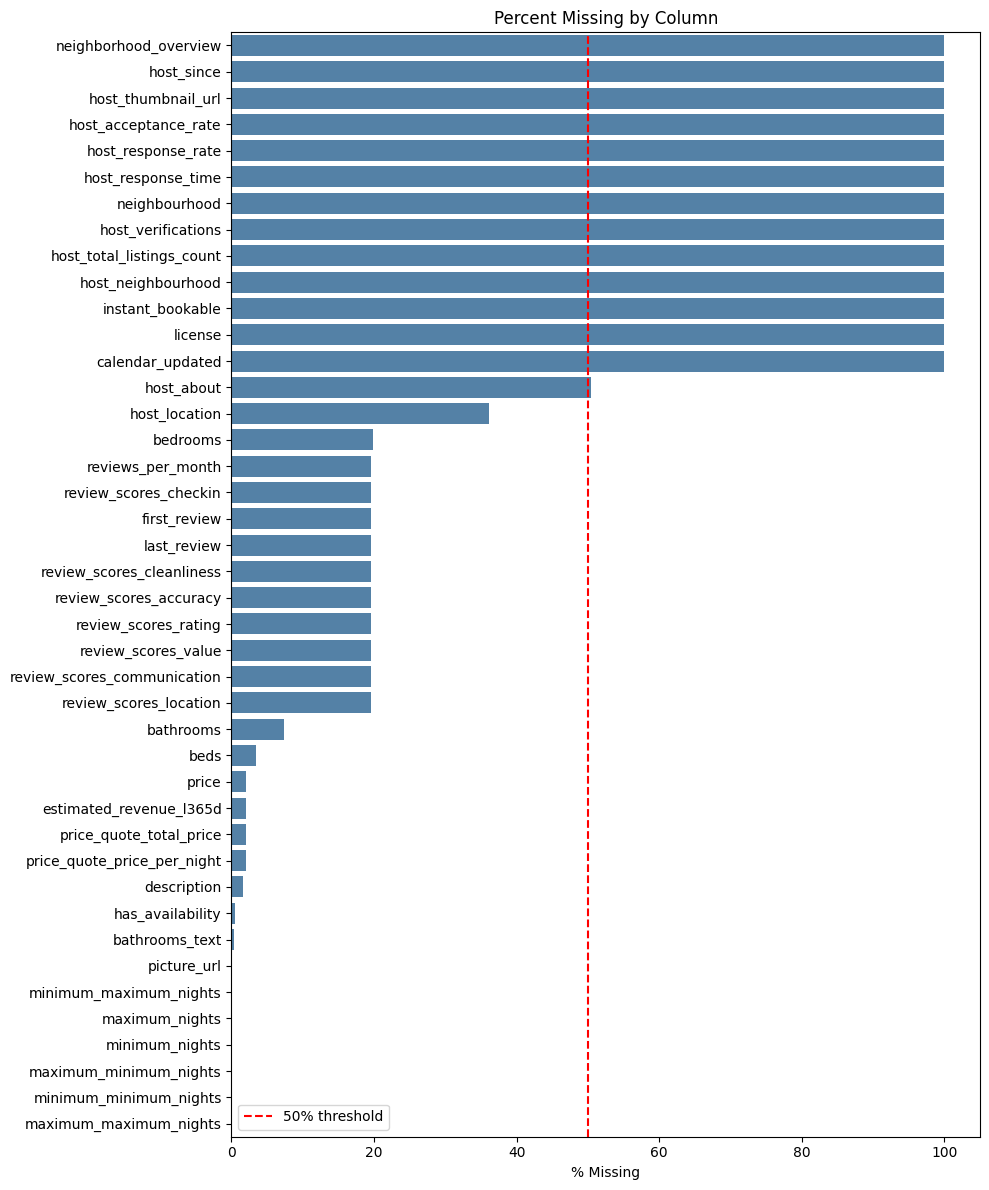

In [22]:
plt.figure(figsize=(10, 12))
sns.barplot(x=missing['null_pct'], y=missing.index, color='steelblue')
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.title('Percent Missing by Column')
plt.xlabel('% Missing')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

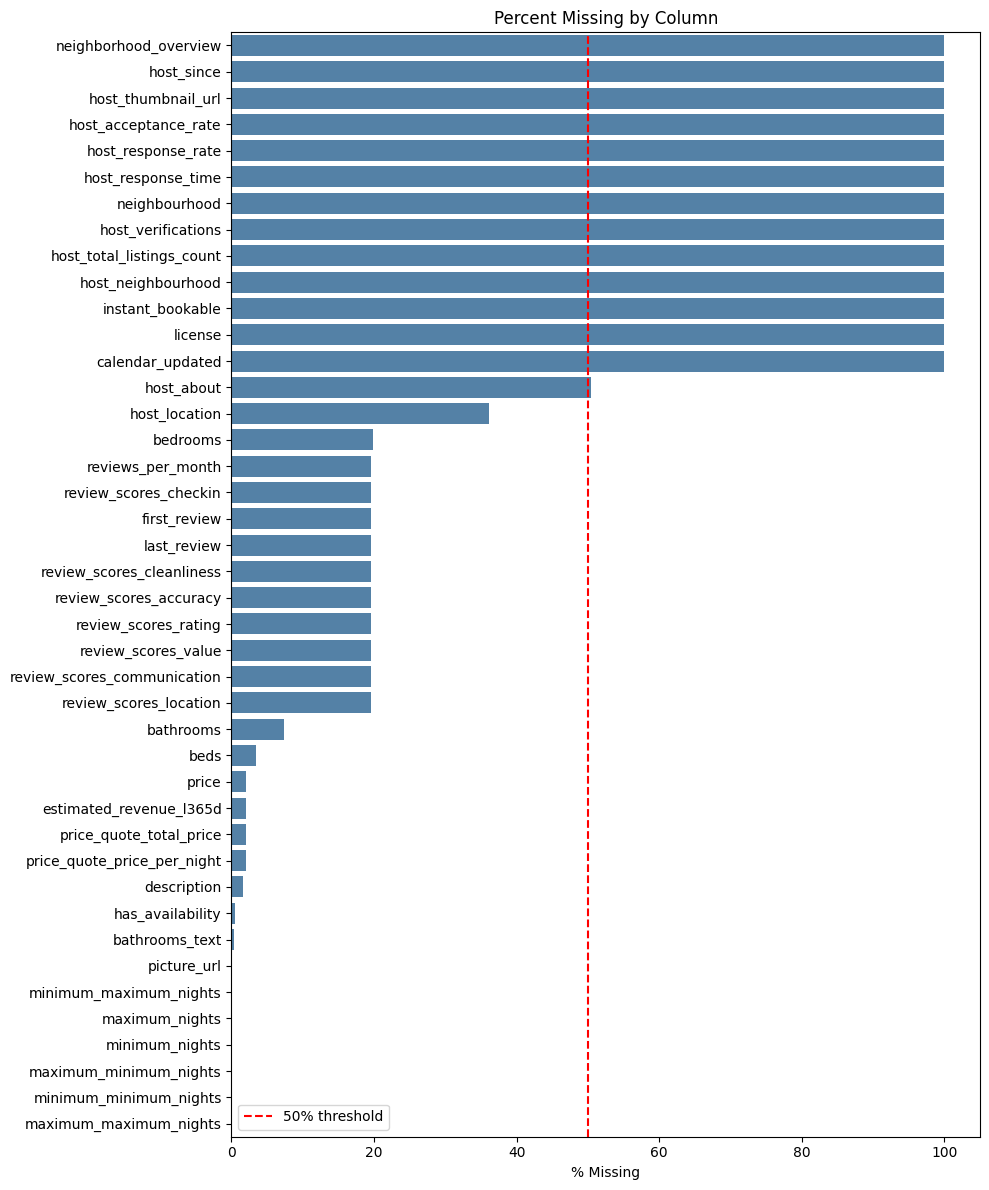

In [23]:
plt.figure(figsize=(10, 12))
sns.barplot(x=missing['null_pct'], y=missing.index, color='steelblue')
plt.axvline(50, color='red', linestyle='--', label='50% threshold')
plt.title('Percent Missing by Column')
plt.xlabel('% Missing')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. The top 3 columns with missing values are host response rate, host acceptance rate, and host since. these are completely empty. other columns with missing data are heighborhood, licence, and instant bookable.

2. The column thats likely to cause issues is pricing and bedrooms. Pricing is only missing about 2% but its a very important variable for people to see and helps track revenue. Bedrooms is around 20% missing and also important because it hurts comparison by property size.

3.The other columns like host acceptance rate, host response rate, and host since can all be dropped from the data set because they don't give anything to work with. They don't play a key role in analyzing the data.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [24]:
cols_to_drop = [
    'calendar_updated',
    'license',
    'neighbourhood',
    'host_about'
]

df = df.drop(columns=cols_to_drop)


print(f"New shape: {df.shape}")
print([c for c in cols_to_drop if c in df.columns])
df.info()

New shape: (6930, 86)
[]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6930 entries, 0 to 6929
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6930 non-null   int64  
 1   listing_url                                   6930 non-null   object 
 2   scrape_id                                     6930 non-null   int64  
 3   last_scraped                                  6930 non-null   object 
 4   source                                        6930 non-null   object 
 5   name                                          6930 non-null   object 
 6   description                                   6818 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   6929 non-null   object 
 9   host_id                               

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped columns: calender updated, license, neighbourhood and host about.
2. 3 of these columns were completely empty so they aren't important to me and neighborhood was repetitive since the neighborhood cleansed already gave me the location data I need. These columns are hard to turn into anything measurable for my analysis.
3. Leaving these missing and repetitive datasets in makes it messy to go through and could cause me to analyze things in a wrong way. If someone else were to use this with those left in it may cause them problems. Empty columns can also leading to breaking models or forcing rows to be dropped.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [25]:

df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

df['price_was_missing'] = df['price'].isna()

df['price'] = df['price'].fillna(df.groupby('room_type')['price'].transform('median'))

print("Missing prices after fill:", df['price'].isna().sum())
print(df.groupby('room_type')['price'].median())

Missing prices after fill: 0
room_type
Entire home/apt    141.50
Hotel room          62.00
Private room        53.00
Shared room         30.46
Name: price, dtype: float64


In [26]:

df['has_reviews'] = df['review_scores_rating'].notna()
df['rating_label'] = df['review_scores_rating'].round(2).astype(str).replace('nan', 'No reviews yet')

print(df['has_reviews'].value_counts())
df[['price', 'price_was_missing', 'review_scores_rating', 'has_reviews', 'rating_label']].head(10)

has_reviews
True     5571
False    1359
Name: count, dtype: int64


,price,price_was_missing,review_scores_rating,has_reviews,rating_label
0,76.00,False,4.92,True,4.92
1,67.00,False,4.81,True,4.81
2,190.00,False,4.90,True,4.9
3,30.00,False,5.00,True,5.0
4,101.00,False,4.98,True,4.98
5,55.50,False,4.90,True,4.9
6,41.00,False,4.78,True,4.78
7,154.00,False,4.64,True,4.64
8,50.00,False,4.92,True,4.92
9,59.13,False,4.70,True,4.7


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned the price column and the review scores rating column.

2. For the price column I converted the text into numbers and then filled the missing values with the median price for listings of that room type. For the review scores rating I changed it so that the missing ratings means thats they havent been reviewed yet.

3. The risks in me filling the data this way is that the pricings are estimatwes and could not be exactly why they actual are. Meaning that something super expensive in a nice neighbourhood could be priced wrong. If people ignore the flag they could end up having very inaccuratly skewed data. In terms of the ratings leaving them empty means that scores are arly counted by reviewed listings which might make the market look better or worse than it actually is.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

In [27]:

print("Before:", df['last_review'].dtype)
print(df['last_review'].head())

df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

print("\nAfter:", df['last_review'].dtype)
print(df['last_review'].describe())

Before: object
0    2026-06-07
1    2026-03-02
2    2026-06-17
3    2018-11-23
4    2026-06-28
Name: last_review, dtype: object

After: datetime64[ns]
count                             5571
mean     2026-01-29 16:20:56.219709440
min                2015-01-03 00:00:00
25%                2026-03-01 00:00:00
50%                2026-05-31 00:00:00
75%                2026-06-19 00:00:00
max                2026-06-28 00:00:00
Name: last_review, dtype: object


In [28]:
snapshot = df['last_review'].max()
df['days_since_last_review'] = (snapshot - df['last_review']).dt.days
print(df['days_since_last_review'].describe())

count    5571.000000
mean      149.318794
std       332.480045
min         0.000000
25%         9.000000
50%        28.000000
75%       119.000000
max      4194.000000
Name: days_since_last_review, dtype: float64


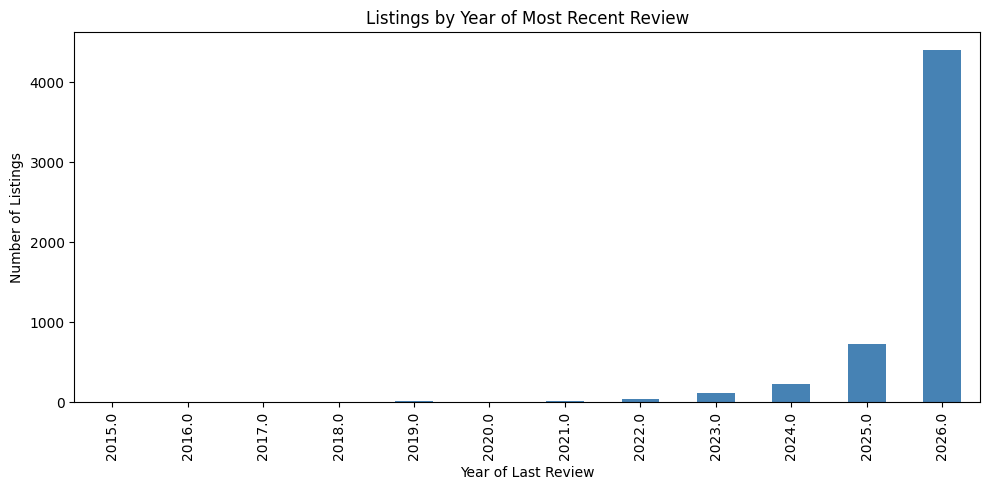

In [29]:
df['last_review'].dt.year.value_counts().sort_index().plot(kind='bar', color='steelblue', figsize=(10, 5))
plt.title('Listings by Year of Most Recent Review')
plt.xlabel('Year of Last Review')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the last review column so that instead of storing data as text it switched it to dates.

2. The cleaning steps I took to convert it was pd.to_datetime and errors='coerce' so that the bad values could end up blank and not crash the code. I then compared the data before and after to check the date ranges from 2015 to 2026. the only blanks now are the ones with missing count since they had no reviews.

3. These helps me prepare the data for later use because it can be sorted and filtered via the dates. It makes it mauch easier to find listings that could be inactive, track activity over time, and help with overal performance of a model.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [30]:
print("Exact duplicate rows:", df.duplicated().sum())

print("Duplicate IDs:", df['id'].duplicated().sum())
print("Unique IDs:", df['id'].nunique(), "| Total rows:", len(df))

before = len(df)
df = df.drop_duplicates()
df = df.drop_duplicates(subset='id', keep='first')
print(f"Rows removed: {before - len(df)} | Rows remaining: {len(df)}")

Exact duplicate rows: 0
Duplicate IDs: 0
Unique IDs: 6930 | Total rows: 6930
Rows removed: 0 | Rows remaining: 6930


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. I didn't find any duplicates and found that all the IDs were unique.

2. I used ID as my biggest helper here because it is supposed ot be unique. Using this I checked to see if rows had repeating IDs which there was none.

3. Duplicates are risky for the Airbnb teams because they make it so that there is two or more of the same listing. This can lead to revenue overestimates, along with skewing the average prices or review scores. People working on this could then have data that looks much bigger then it is leading to bad decision making.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [31]:
# export csv here 🔧

empty_cols = df.columns[df.isnull().all()].tolist()
df = df.drop(columns=empty_cols)
print("Dropped empty columns:", empty_cols)

for col in ['first_review', 'last_scraped', 'calendar_last_scraped']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

tf_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'has_availability']
for col in tf_cols:
    df[col] = df[col].map({'t': True, 'f': False})

print(f"\nFinal shape: {df.shape}")
print(df.dtypes.value_counts())
df.info()

Dropped empty columns: ['neighborhood_overview', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url', 'host_neighbourhood', 'host_total_listings_count', 'host_verifications', 'instant_bookable']

Final shape: (6930, 80)
float64           26
int64             24
object            21
bool               5
datetime64[ns]     4
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6930 entries, 0 to 6929
Data columns (total 80 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            6930 non-null   int64         
 1   listing_url                                   6930 non-null   object        
 2   scrape_id                                     6930 non-null   int64         
 3   last_scraped                                  6930 non-null   datetime64[ns]

In [32]:
df.to_csv('/content/listings_cleaned.csv', index=False)
print("Saved to /content/listings_cleaned.csv")

from google.colab import files
files.download('/content/listings_cleaned.csv')

Saved to /content/listings_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. The part that I found most challenging was step 4 with filling the missing values. I had trouble with the code but also more so with deciding which method made sense for the columns. The class concepts were harder for me hear because during the coding I had to decide which type of filling missing data was right so I had to go back over last weeks reading briefly and think it through.
2. The one that comes to mind here was in the review scores rating section and why I decided not to drop the missing data because I realized that those places had yet to be reviewed yet. The way I went about doing it made it so that the information was preserved and the data is still useable.   
3. Pricing anlysts could benefit now because they have the ability to see price numerically with no gaps. Along with that the estimated prices using the median are flagged so that they could leave them out if needed or check with they are inactive or the contact a host.   
4. What I'd do with more time or if I was actually at a job working on this dataset is looking into the 17 near dublicate listings to see if they are repeat posts or seperate units. I'd also go deeper on the pricing and look at the outliers to see how they may have skewed the averages.   
5.  This assignment was yet another on that directly connected to my leanring outcomes and what I want to get out of this course which is hand on experience with real data, and leanring how to use code to help me anlayze it using the crisp DM system that we are going over in class. This assignment felt really realistic to something I could actually do in a job post grad and I am greatful to have bettered my skillset in python and with anlyzing data.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [34]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] Converting notebook assignment_06_data_cleaning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 707474 bytes to assignment_06_data_cleaning.html
